# Ingeniería del Dato - TFG IBEX 35

**Autor:** Alonso Gil  
**Tutor:** Julio Emilio Sandubete Galán  
**Universidad:** Francisco de Vitoria (UFV)  
**Grado:** Business Analytics

---

Este notebook implementa la fase de **ingeniería del dato** del trabajo de clasificación de riesgo en el IBEX 35, estructurado en las cuatro etapas estándar:

1. **Extracción de datos** - Carga del dataset bruto y construcción de la variable objetivo Y_RiesgoAlto.
2. **Exploración y limpieza** - Análisis de distribuciones, nulos, duplicados y outliers.
3. **Transformaciones** - Normalización con StandardScaler.
4. **Análisis y visualización** - Correlaciones, perfiles por clase y validación visual del score.

**Nota metodológica.** La variable objetivo `Y_RiesgoAlto` no viene dada en el dataset bruto: se construye en este notebook como un **Score Compuesto de Fragilidad Fundamental** basado en cuatro ratios contables (Deuda/Capital, ROA, Liquidez Corriente, EBITDA Margin). El notebook de Análisis posterior utilizará las 14 variables completas como predictores, en línea con la pregunta principal del anteproyecto.

## 0. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 3.2.1 Extracción de datos

In [2]:
# Carga del dataset bruto
df = pd.read_excel('BaseDeDatosTFG.xlsx')
print(f'Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas')
print(f'\nColumnas: {df.columns.tolist()}')
df.head()

Dimensiones: 35 filas y 17 columnas

Columnas: ['Empresa', 'Ticker', 'Sector', 'Vol_Anual', 'Vol_Trim', 'Beta', 'Ret_Anual', 'Ret_Trim', 'PER', 'ROE', 'ROA', 'Price_Book', 'EBITDA_Margin', 'Deuda_Capital', 'Liquidez_Corriente', 'Cap_bn', 'Precio']


,Empresa,Ticker,Sector,Vol_Anual,Vol_Trim,Beta,Ret_Anual,Ret_Trim,PER,ROE,ROA,Price_Book,EBITDA_Margin,Deuda_Capital,Liquidez_Corriente,Cap_bn,Precio
0,Banco Santander,SAN.MC,Financiero,0.2988,0.1872,0.92,78.31,-4.81,12.28,11.80,0.8,1.37,NaN,NaN,NaN,141.44,9.81
1,BBVA,BBVA.MC,Financiero,0.2908,0.1786,0.92,73.48,-7.76,10.60,17.90,1.4,1.80,NaN,NaN,NaN,105.50,18.77
2,CaixaBank,CABK.MC,Financiero,0.2589,0.1553,0.11,68.67,-1.56,13.20,14.90,0.9,1.90,NaN,NaN,NaN,72.74,10.38
3,Banco Sabadell,SAB.MC,Financiero,0.3147,0.1419,0.57,43.40,2.50,12.34,8.60,0.7,1.08,NaN,NaN,NaN,15.09,3.23
4,Bankinter,BKT.MC,Financiero,0.2550,0.1095,-0.01,60.20,3.10,12.39,17.74,0.9,2.03,NaN,NaN,NaN,13.03,14.50


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Empresa             35 non-null     object 
 1   Ticker              35 non-null     object 
 2   Sector              35 non-null     object 
 3   Vol_Anual           35 non-null     float64
 4   Vol_Trim            35 non-null     float64
 5   Beta                34 non-null     float64
 6   Ret_Anual           35 non-null     float64
 7   Ret_Trim            35 non-null     float64
 8   PER                 35 non-null     float64
 9   ROE                 35 non-null     float64
 10  ROA                 35 non-null     float64
 11  Price_Book          35 non-null     float64
 12  EBITDA_Margin       28 non-null     float64
 13  Deuda_Capital       28 non-null     float64
 14  Liquidez_Corriente  28 non-null     float64
 15  Cap_bn              35 non-null     float64
 16  Precio    

In [6]:
# Verificar unicidad
print(f'Filas duplicadas:    {df.duplicated().sum()}')
print(f'Tickers duplicados:  {df["Ticker"].duplicated().sum()}')

Filas duplicadas:    0
Tickers duplicados:  0


### Construcción de la variable objetivo Y_RiesgoAlto

El target se construye como un **Score Compuesto de Fragilidad Fundamental** basado en cuatro ratios contables:

$$\text{Score} = 0{,}25\,z(\text{Deuda\_Capital}) - 0{,}25\,z(\text{ROA}) - 0{,}25\,z(\text{Liquidez\_Corriente}) - 0{,}25\,z(\text{EBITDA\_Margin})$$

$$Y\_\text{RiesgoAlto} = \begin{cases} 1 & \text{si Score} > \text{mediana} \\ 0 & \text{en caso contrario} \end{cases}$$

Esta operacionalización sigue la tradición clásica de Beaver (1966), Altman (1968) y Ohlson (1980).

 Para construir el Score necesitamos valores no nulos en las 4 variables contables. Por ello hacemos aquí una **imputación temporal local sobre una copia del DataFrame** (`df_temp`), exclusivamente para el cálculo del score. El DataFrame original `df` no se modifica todavía. En la sección 3.2.2 se realizará la **imputación definitiva** sobre el DataFrame principal, con valores idénticos por reproducibilidad.

In [7]:
# IMPUTACIÓN TEMPORAL LOCAL (solo para calcular el Score, sobre una COPIA)
df_temp = df.copy()
for col in ['Deuda_Capital', 'Liquidez_Corriente', 'EBITDA_Margin']:
    df_temp[col] = df_temp[col].fillna(df_temp[col].median())

def z_score(serie):
    return (serie - serie.mean()) / serie.std()

# Score Compuesto de Fragilidad
df['Score_Fragilidad'] = (
    + 0.25 * z_score(df_temp['Deuda_Capital'])
    - 0.25 * z_score(df_temp['ROA'])
    - 0.25 * z_score(df_temp['Liquidez_Corriente'])
    - 0.25 * z_score(df_temp['EBITDA_Margin'])
)

# Variable binaria
umbral = df['Score_Fragilidad'].median()
df['Y_RiesgoAlto'] = (df['Score_Fragilidad'] > umbral).astype(int)

print(f'Umbral (mediana del score): {umbral:.4f}')
print(f'\nDistribución de Y_RiesgoAlto:')
print(df['Y_RiesgoAlto'].value_counts().sort_index())
print(f'\nPorcentajes:')
print((df['Y_RiesgoAlto'].value_counts(normalize=True).sort_index()*100).round(1))

Umbral (mediana del score): 0.0851

Distribución de Y_RiesgoAlto:
Y_RiesgoAlto
0    18
1    17
Name: count, dtype: int64

Porcentajes:
Y_RiesgoAlto
0    51.4
1    48.6
Name: proportion, dtype: float64


In [8]:
# Top 5 empresas con MENOR fragilidad (riesgo BAJO esperado)
print('TOP 5 EMPRESAS CON MENOR FRAGILIDAD (riesgo BAJO):')
print(df.nsmallest(5, 'Score_Fragilidad')[
    ['Empresa', 'Sector', 'Score_Fragilidad',
     'Deuda_Capital', 'ROA', 'Liquidez_Corriente', 'EBITDA_Margin']
].to_string(index=False))

TOP 5 EMPRESAS CON MENOR FRAGILIDAD (riesgo BAJO):
          Empresa           Sector  Score_Fragilidad  Deuda_Capital   ROA  Liquidez_Corriente  EBITDA_Margin
Laboratorios Rovi            Salud         -1.652907           0.18 12.11                3.13          26.30
             Aena Infraestructuras         -1.216414           0.83 12.30                1.88          58.07
          Inditex          Consumo         -1.130604           0.29 17.70                1.54          23.60
Merlin Properties     Inmobiliario         -0.748537           0.63  5.70                1.18          75.42
       Amadeus IT       Tecnología         -0.456237           0.67 11.50                0.82          37.55


In [ ]:
# Top 5 empresas con MAYOR fragilidad (riesgo ALTO esperado)
print('TOP 5 EMPRESAS CON MAYOR FRAGILIDAD (riesgo ALTO):')
print(df.nlargest(5, 'Score_Fragilidad')[
    ['Empresa', 'Sector', 'Score_Fragilidad',
     'Deuda_Capital', 'ROA', 'Liquidez_Corriente', 'EBITDA_Margin']
].to_string(index=False))

TOP 5 EMPRESAS CON MAYOR FRAGILIDAD (riesgo ALTO):
     Empresa       Sector  Score_Fragilidad  Deuda_Capital   ROA  Liquidez_Corriente  EBITDA_Margin
  Telefónica      Telecom          1.166686           2.35 -4.30                0.89          19.79
       Sacyr Construcción          1.125053           3.85  1.80                1.04          26.29
         ACS Construcción          0.997564           2.99  2.80                1.16           4.23
     Acciona Construcción          0.715801           2.15  1.98                1.19           8.84
IAG (Iberia)   Transporte          0.419368           1.88  7.70                0.70          18.98


### Sobre la posible sospecha de circularidad

Conviene anticipar una objeción legítima: dado que 4 de los 14 predictores que usaremos en el notebook de Análisis (Deuda_Capital, ROA, Liquidez_Corriente y EBITDA_Margin) son precisamente las variables que componen el Score de Fragilidad, podría sospecharse que los modelos no aprenden capacidad predictiva real, sino que se limitan a reproducir la fórmula del score.

Esta preocupación se aborda en la **sección 3.3.7 de la memoria de Análisis del Dato** mediante un **experimento de robustez en 4 escenarios**:

| Escenario | Configuración | Acc LOOCV | AUC |
|---|---|---|---|
| E1 | Solo 4 vars del score | 91.4% | 0.98 |
| **E2** | **14 vars completas (TFG)** | **80.0%** | **0.88** |
| E3 | Solo 10 vars no-score | 37.1% | 0.29 |
| E4 | 14 vars + etiquetas ALEATORIAS | 54.3% | 0.55 |

Si la circularidad fuese trivial, los modelos alcanzarían el 100% y también darían 80% con etiquetas aleatorias (E4). Lo que ocurre es lo contrario: el modelo aprende patrones reales en E2 y reconoce la ausencia de señal en E4. Esto **descarta empíricamente** la sospecha de circularidad trivial.

### Naturaleza relativa de la clasificación

Una segunda observación importante: la clasificación Y_RiesgoAlto es **relativa al universo analizado**, no absoluta. Al usar la mediana del Score como umbral, la asignación de cada empresa depende de la distribución conjunta de las 35 empresas del IBEX 35 actual.

Implicaciones:

- Si añadimos una empresa nueva, la mediana se desplaza ligeramente y algunas empresas próximas al umbral podrían cambiar de clase.
- El modelo es directamente aplicable al universo del IBEX 35 actual.
- Para extrapolarlo a empresas externas al índice o a versiones futuras del IBEX 35 con composición distinta, sería necesario **recalibrar** tanto el cálculo del Score como el umbral.

Esta limitación es consustancial a cualquier operacionalización basada en estadísticos relativos al dataset, y se reconoce explícitamente en las líneas futuras del trabajo.

**Validación de coherencia financiera del score:**

- Las 5 empresas con menor fragilidad (Rovi, Aena, Inditex, Merlin, Amadeus) son reconocidas por su solidez financiera.
- Las 5 con mayor fragilidad (Telefónica, Sacyr, ACS, Acciona, IAG) presentan ratios de deuda elevados y/o ROA bajos.

**Observación sobre los bancos:** los 6 bancos del IBEX 35 carecen de 3 de las 4 variables del score (no aplicables a la contabilidad bancaria). Tras la imputación por mediana, su clasificación quedará determinada **únicamente por su ROA**. Se discute en la memoria.

## 3.2.2 Exploración y limpieza

### Análisis de la distribución de las variables

Antes de tratar nulos y outliers, examinamos las distribuciones de cada variable mediante histogramas.

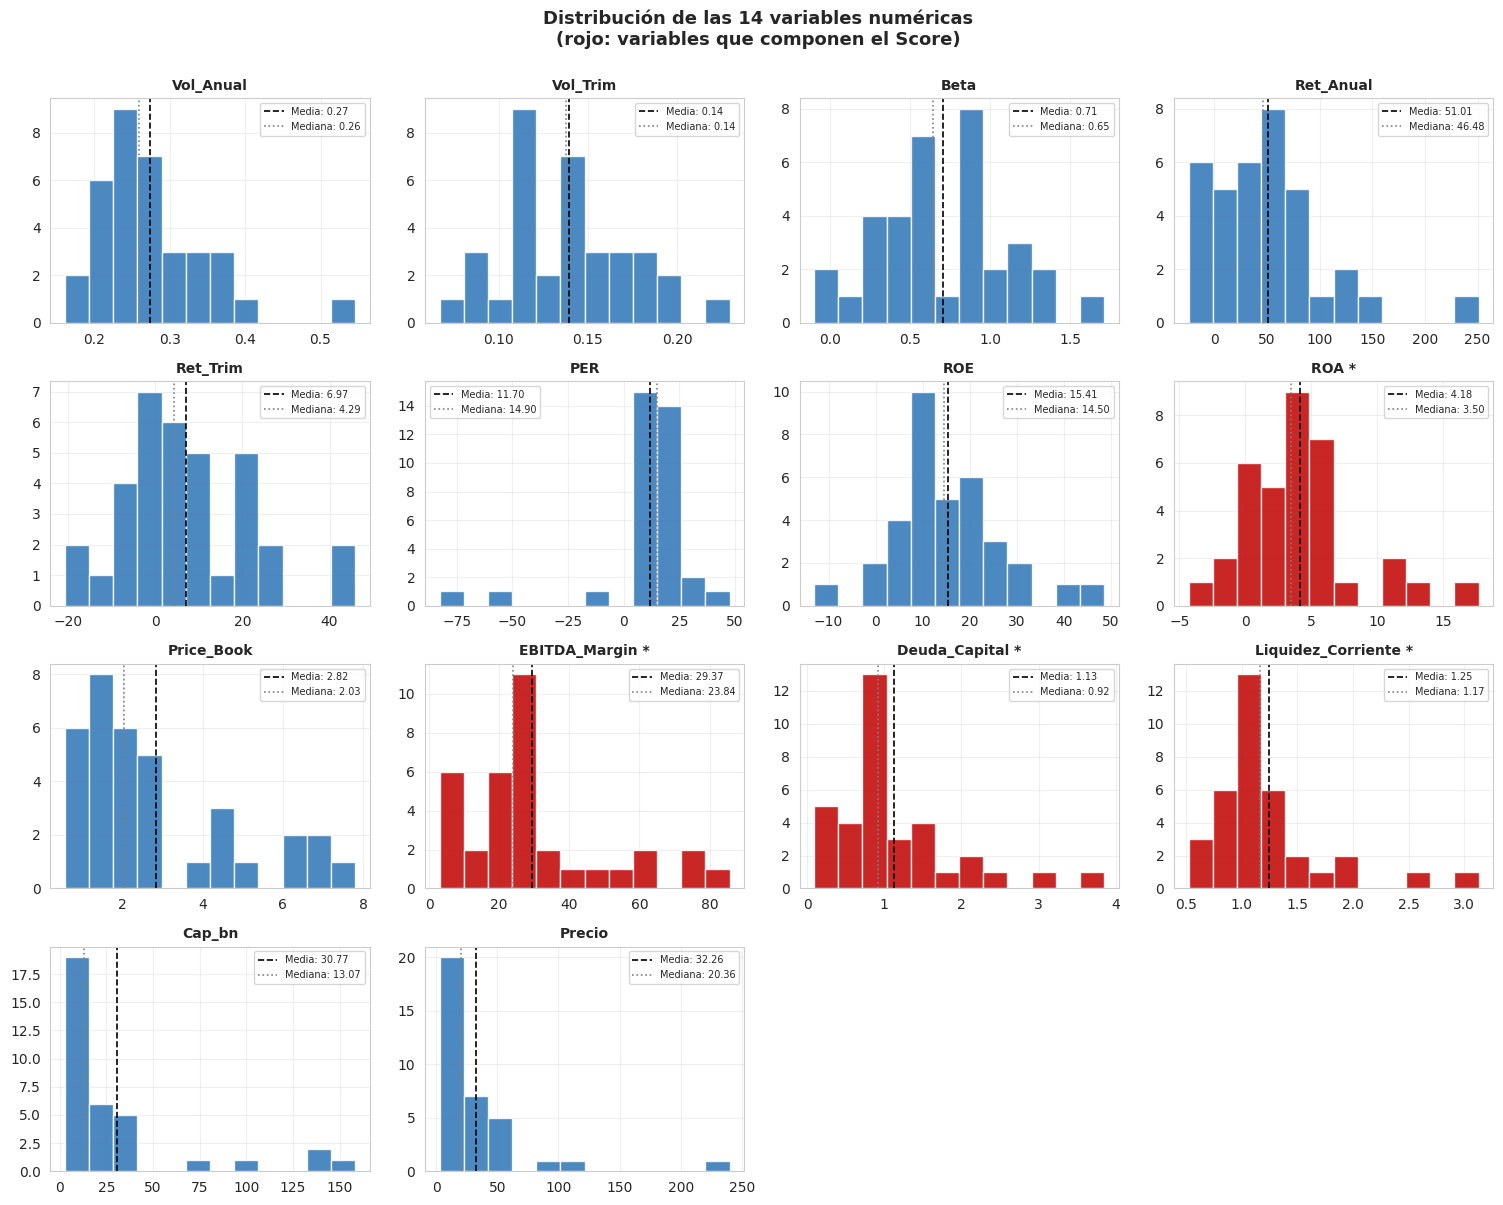

In [9]:
VARS_NUM = ['Vol_Anual', 'Vol_Trim', 'Beta', 'Ret_Anual', 'Ret_Trim',
            'PER', 'ROE', 'ROA', 'Price_Book', 'EBITDA_Margin',
            'Deuda_Capital', 'Liquidez_Corriente', 'Cap_bn', 'Precio']
VARS_SCORE = ['Deuda_Capital', 'ROA', 'Liquidez_Corriente', 'EBITDA_Margin']

# Histogramas con imputación temporal sobre COPIA para visualizar
df_viz = df.copy()
for col in ['Deuda_Capital', 'Liquidez_Corriente', 'EBITDA_Margin', 'Beta']:
    df_viz[col] = df_viz[col].fillna(df_viz[col].median())

fig, axes = plt.subplots(4, 4, figsize=(15, 12))
for ax, var in zip(axes.flatten(), VARS_NUM):
    es_score = var in VARS_SCORE
    color = '#C00000' if es_score else '#2E75B6'
    ax.hist(df_viz[var], bins=12, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df_viz[var].mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'Media: {df_viz[var].mean():.2f}')
    ax.axvline(df_viz[var].median(), color='gray', linestyle=':', linewidth=1.2,
               label=f'Mediana: {df_viz[var].median():.2f}')
    titulo = var + ' *' if es_score else var
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
for ax in axes.flatten()[len(VARS_NUM):]:
    ax.axis('off')
fig.suptitle('Distribución de las 14 variables numéricas\n(rojo: variables que componen el Score)',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

**Observaciones de los histogramas:**

- **Asimetría positiva** en Cap_bn, Precio, PER, Price_Book y Deuda_Capital: la mayoría de empresas en valores bajos con colas hacia la derecha.
- **Diferencia entre media y mediana** notable en variables asimétricas (ej. Cap_bn: media 30.77 vs mediana 13.07), lo que justifica el uso de la **mediana** tanto para imputación como para el umbral del score (más robusta frente a outliers).
- **Rangos muy distintos** entre variables: Cap_bn (2-158) vs Vol_Anual (0.16-0.55), lo que justifica la **normalización con StandardScaler** que aplicaremos después.
- Las 4 variables del score (en rojo) presentan distribuciones suficientemente variables para capturar diferencias entre empresas.

### Análisis de valores nulos

In [10]:
# Recuento de nulos
nulos = df[VARS_NUM].isnull().sum()
print('Nulos por variable:')
print(nulos[nulos > 0])
print(f'\nTotal nulos: {nulos.sum()} de {35*14} celdas ({nulos.sum()/(35*14)*100:.1f}%)')

Nulos por variable:
Beta                  1
EBITDA_Margin         7
Deuda_Capital         7
Liquidez_Corriente    7
dtype: int64

Total nulos: 22 de 490 celdas (4.5%)


In [11]:
# Empresas con nulos en variables fundamentales
mask = df[['EBITDA_Margin', 'Deuda_Capital', 'Liquidez_Corriente', 'Beta']].isnull().any(axis=1)
print('Empresas con nulos en ratios fundamentales o Beta:')
df.loc[mask, ['Empresa', 'Sector', 'Deuda_Capital', 'ROA',
              'Liquidez_Corriente', 'EBITDA_Margin', 'Beta']]

Empresas con nulos en ratios fundamentales o Beta:


,Empresa,Sector,Deuda_Capital,ROA,Liquidez_Corriente,EBITDA_Margin,Beta
0,Banco Santander,Financiero,NaN,0.80,NaN,NaN,0.92
1,BBVA,Financiero,NaN,1.40,NaN,NaN,0.92
2,CaixaBank,Financiero,NaN,0.90,NaN,NaN,0.11
3,Banco Sabadell,Financiero,NaN,0.70,NaN,NaN,0.57
4,Bankinter,Financiero,NaN,0.90,NaN,NaN,-0.01
5,Unicaja Banco,Financiero,NaN,0.65,NaN,NaN,0.38
6,Mapfre,Seguros,0.26,3.10,1.29,NaN,0.24
15,Redeia,Energía,NaN,3.50,NaN,62.08,0.47
34,Puig Brands,Consumo,0.45,6.10,1.12,19.13,NaN


**Patrón estructural de nulos:**

- **6 bancos** (Santander, BBVA, CaixaBank, Sabadell, Bankinter, Unicaja): Deuda/Capital, Liquidez_Corriente y EBITDA_Margin no son aplicables a la contabilidad bancaria.
- **Mapfre**: misma situación con EBITDA_Margin por ser aseguradora.
- **Redeia**: nulo por falta de dato en la fuente.
- **Puig Brands**: Beta nula porque su IPO fue en mayo 2024 (no 5 años de histórico).

**Decisión:** imputación por mediana, robusta frente a outliers. Esta imputación es la **definitiva** del dataset principal, y produce exactamente los mismos valores numéricos que la imputación temporal local usada en 3.2.1 para calcular el score (garantiza la coherencia del pipeline).

In [12]:
# IMPUTACIÓN DEFINITIVA sobre el DataFrame principal
for col in ['Deuda_Capital', 'Liquidez_Corriente', 'EBITDA_Margin', 'Beta']:
    mediana = df[col].median()
    n = df[col].isnull().sum()
    df[col] = df[col].fillna(mediana)
    print(f'{col:25s} | mediana={mediana:.4f} | imputados {n} nulos')

print(f'\nNulos restantes: {df[VARS_NUM].isnull().sum().sum()}')

Deuda_Capital             | mediana=0.9200 | imputados 7 nulos
Liquidez_Corriente        | mediana=1.1650 | imputados 7 nulos
EBITDA_Margin             | mediana=23.8450 | imputados 7 nulos
Beta                      | mediana=0.6450 | imputados 1 nulos

Nulos restantes: 0


### Detección de outliers (método IQR)

In [13]:
total = 0
print('Outliers por variable:')
print('-' * 50)
for var in VARS_NUM:
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    out = df[(df[var] < lim_inf) | (df[var] > lim_sup)]
    if len(out) > 0:
        print(f'  {var:22s}: {len(out):2d} outliers')
        total += len(out)
print('-' * 50)
print(f'Total: {total} outliers')

Outliers por variable:
--------------------------------------------------
  Vol_Anual             :  1 outliers
  Beta                  :  1 outliers
  Ret_Anual             :  1 outliers
  Ret_Trim              :  2 outliers
  PER                   :  5 outliers
  ROE                   :  2 outliers
  ROA                   :  1 outliers
  EBITDA_Margin         :  5 outliers
  Deuda_Capital         :  2 outliers
  Liquidez_Corriente    :  6 outliers
  Cap_bn                :  4 outliers
  Precio                :  3 outliers
--------------------------------------------------
Total: 33 outliers


**Decisión: mantener todos los outliers en el dataset.**

Todos los valores extremos son **datos reales y financieramente justificables**:
- Solaria: alta volatilidad por ser empresa solar de pequeño tamaño.
- ArcelorMittal: beta de 1.71 por ser empresa de materiales cíclicos.
- ACS, Sacyr, Acciona: alta deuda típica de constructoras.

Con n=35, eliminar cualquier fila compromete la representatividad.

## 3.2.3 Transformaciones

### Normalización con StandardScaler

In [14]:
print('ANTES de la normalización:')
df[VARS_NUM].describe().T[['mean', 'std', 'min', 'max']].round(3)

ANTES de la normalización:


,mean,std,min,max
Vol_Anual,0.273,0.075,0.161,0.546
Vol_Trim,0.139,0.036,0.067,0.229
Beta,0.705,0.407,-0.100,1.710
Ret_Anual,51.005,53.234,-24.390,251.000
Ret_Trim,6.969,14.793,-20.690,45.850
PER,11.703,22.626,-82.700,47.500
ROE,15.405,11.534,-13.100,48.600
ROA,4.176,4.259,-4.300,17.700
Price_Book,2.823,1.998,0.560,7.800
EBITDA_Margin,29.371,21.388,2.970,85.710


In [15]:
scaler = StandardScaler()
df_escalado = pd.DataFrame(
    scaler.fit_transform(df[VARS_NUM]),
    columns=VARS_NUM,
    index=df.index
)

df_final = df.copy()
df_final[VARS_NUM] = df_escalado

print('DESPUÉS de la normalización:')
df_final[VARS_NUM].describe().T[['mean', 'std', 'min', 'max']].round(3)

DESPUÉS de la normalización:


,mean,std,min,max
Vol_Anual,0.0,1.015,-1.526,3.696
Vol_Trim,0.0,1.015,-2.055,2.555
Beta,-0.0,1.015,-2.009,2.508
Ret_Anual,-0.0,1.015,-1.437,3.812
Ret_Trim,-0.0,1.015,-1.897,2.667
PER,-0.0,1.015,-4.233,1.605
ROE,-0.0,1.015,-2.508,2.920
ROA,0.0,1.015,-2.019,3.222
Price_Book,-0.0,1.015,-1.149,2.527
EBITDA_Margin,-0.0,1.015,-1.252,2.673


### Análisis de correlaciones con Y_RiesgoAlto

In [16]:
corrs = df_final[VARS_NUM + ['Y_RiesgoAlto']].corr()
corr_con_y = corrs['Y_RiesgoAlto'].drop('Y_RiesgoAlto').sort_values(key=abs, ascending=False)

print('Correlación de Pearson con Y_RiesgoAlto:')
print('-' * 60)
for var, r in corr_con_y.items():
    signo = '+' if r > 0 else ''
    marca = ' (componente del score)' if var in VARS_SCORE else ''
    print(f'  {var:22s} {signo}{r:.4f}{marca}')

Correlación de Pearson con Y_RiesgoAlto:
------------------------------------------------------------
  ROA                    -0.5808 (componente del score)
  EBITDA_Margin          -0.4386 (componente del score)
  Deuda_Capital          +0.3681 (componente del score)
  Liquidez_Corriente     -0.2758 (componente del score)
  PER                    -0.2666
  Vol_Anual              +0.1342
  Precio                 +0.1320
  Cap_bn                 +0.0929
  Ret_Anual              +0.0915
  ROE                    -0.0761
  Beta                   +0.0692
  Price_Book             -0.0542
  Vol_Trim               -0.0402
  Ret_Trim               +0.0080


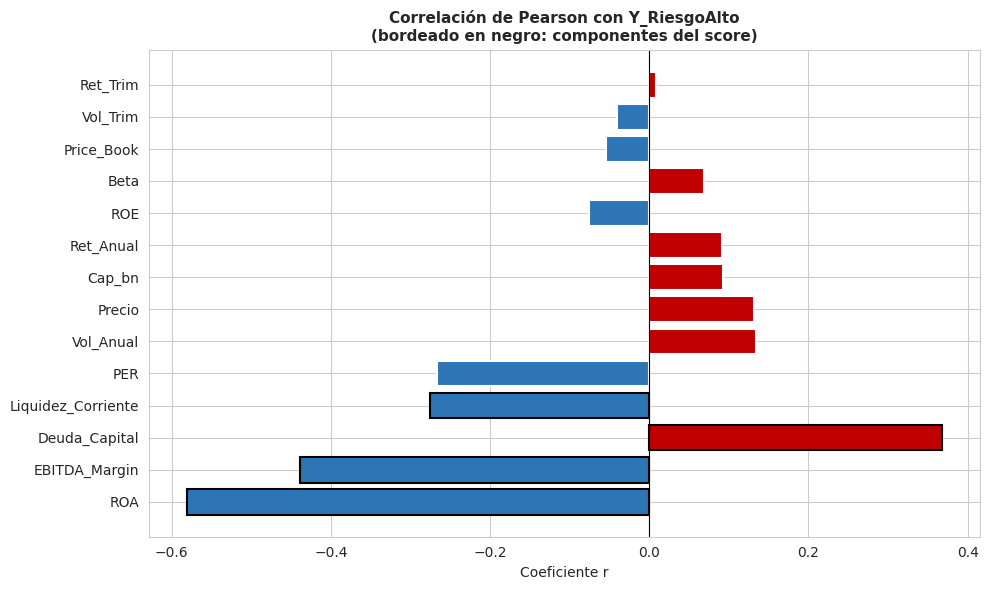

In [17]:
# Visualización con resaltado de variables del score
plt.figure(figsize=(10, 6))
colores = ['#C00000' if v > 0 else '#2E75B6' for v in corr_con_y.values]
es_score = np.array([v in VARS_SCORE for v in corr_con_y.index])
edge = ['black' if e else 'white' for e in es_score]
plt.barh(corr_con_y.index, corr_con_y.values, color=colores, edgecolor=edge, linewidth=1.5)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlación de Pearson con Y_RiesgoAlto\n(bordeado en negro: componentes del score)',
          fontsize=11, fontweight='bold')
plt.xlabel('Coeficiente r')
plt.tight_layout()
plt.show()

### Lectura crítica del ranking de correlaciones
Las 4 variables del score ocupan los primeros puestos del ranking. **Aunque podría parecer trivial** que estos cuatro indicadores lideren el ranking por estar incluidos en la fórmula del target, conviene interpretarlo como **validación de coherencia teórica** más que como tautología matemática:

- La construcción del score sigue la **jerarquía financiera clásica** establecida por Beaver (1966), Altman (1968) y Ohlson (1980), que identifica precisamente estas cuatro dimensiones (rentabilidad, eficiencia operativa, apalancamiento y liquidez) como determinantes fundamentales del riesgo.
- Que **ROA aparezca como la variable más correlacionada** con el riesgo (r = -0.58) no es accidente: es la confirmación de un patrón identificado hace más de medio siglo en la literatura académica (Beaver, 1966).
- Si el ranking hubiera arrojado un orden distinto y contradictorio con la teoría, sería indicio de que el dataset o el score tienen problemas. El hecho de que **respete la jerarquía clásica refuerza la validez** de la operacionalización.

De las 10 variables externas al score: PER (r=-0.27) muestra correlación apreciable; Vol_Anual (r=+0.13) y Beta (r=+0.07) más débiles individualmente. Estas correlaciones marginales son coherentes con la idea de que las variables de mercado pueden aportar información **complementaria** cuando se combinan con los ratios contables en un modelo multivariante. Esta hipótesis se verifica en el notebook de Análisis.

## 3.2.4 Análisis y visualización

### Score de Fragilidad por empresa

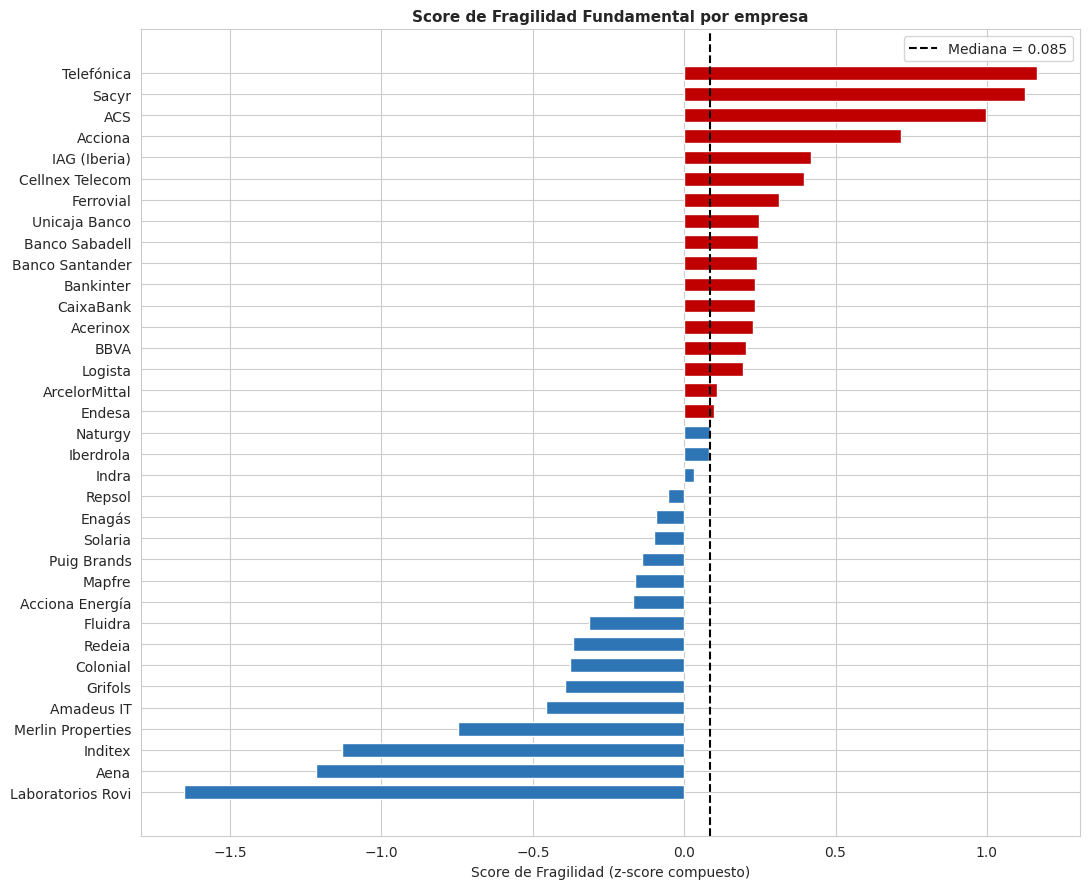

In [18]:
df_sorted = df.sort_values('Score_Fragilidad').reset_index(drop=True)

plt.figure(figsize=(11, 9))
colores = ['#C00000' if v == 1 else '#2E75B6' for v in df_sorted['Y_RiesgoAlto']]
plt.barh(df_sorted['Empresa'], df_sorted['Score_Fragilidad'],
         color=colores, edgecolor='white', height=0.65)
plt.axvline(df_sorted['Score_Fragilidad'].median(), color='black',
            linestyle='--', linewidth=1.5,
            label=f'Mediana = {df_sorted["Score_Fragilidad"].median():.3f}')
plt.title('Score de Fragilidad Fundamental por empresa', fontsize=11, fontweight='bold')
plt.xlabel('Score de Fragilidad (z-score compuesto)')
plt.legend()
plt.tight_layout()
plt.show()

**Observa el agrupamiento estrecho de los 6 bancos** justo por encima del umbral. Esto refleja que sus scores quedan determinados únicamente por su ROA tras la imputación.

### Validación visual de la separación entre clases

Validamos la calidad de la variable objetivo comparando boxplots de las 4 variables del score por clase.

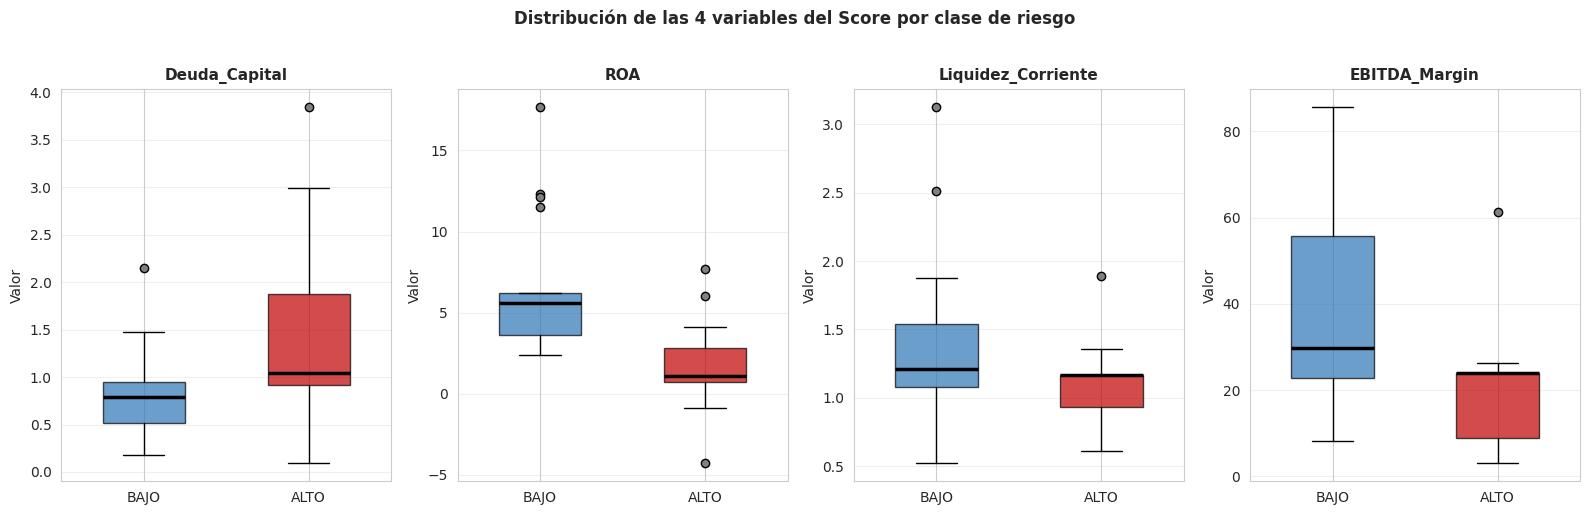

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, var in zip(axes, VARS_SCORE):
    datos = [df[df['Y_RiesgoAlto']==0][var].values,
             df[df['Y_RiesgoAlto']==1][var].values]
    bp = ax.boxplot(datos, tick_labels=['BAJO', 'ALTO'], patch_artist=True,
                    medianprops={'color':'black', 'linewidth':2.5},
                    widths=0.5,
                    flierprops={'marker':'o', 'markersize':6,
                                'markerfacecolor':'gray', 'markeredgecolor':'black'})
    bp['boxes'][0].set_facecolor('#2E75B6')
    bp['boxes'][1].set_facecolor('#C00000')
    for b in bp['boxes']:
        b.set_alpha(0.7)
    ax.set_title(var, fontsize=11, fontweight='bold')
    ax.set_ylabel('Valor', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
fig.suptitle('Distribución de las 4 variables del Score por clase de riesgo',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretación de los boxplots:**

- **Deuda_Capital**: la mediana del grupo ALTO duplica la del BAJO. El outlier superior es Sacyr (3.85).
- **ROA**: el grupo BAJO tiene mediana ~5.5%, el grupo ALTO ~1% (con algunos casos negativos).
- **EBITDA_Margin**: BAJO alcanza 30%, ALTO 20%, con mucha más variabilidad en BAJO (hasta 85%).
- **Liquidez_Corriente**: separación más sutil pero coherente.

Las cuatro dimensiones muestran **separación clara entre clases**, lo que confirma que el score captura un patrón real.

### Perfil medio por clase de riesgo

In [20]:
perfil = df.groupby('Y_RiesgoAlto')[
    ['Deuda_Capital', 'ROA', 'Liquidez_Corriente', 'EBITDA_Margin',
     'Vol_Anual', 'Beta', 'PER', 'ROE']
].mean().round(3)
perfil.index = ['BAJO (0)', 'ALTO (1)']
print('Perfil medio por clase:')
perfil.T

Perfil medio por clase:


,BAJO (0),ALTO (1)
Deuda_Capital,0.842,1.426
ROA,6.545,1.667
Liquidez_Corriente,1.381,1.106
EBITDA_Margin,38.357,19.857
Vol_Anual,0.264,0.284
Beta,0.678,0.734
PER,17.482,5.585
ROE,16.246,14.515


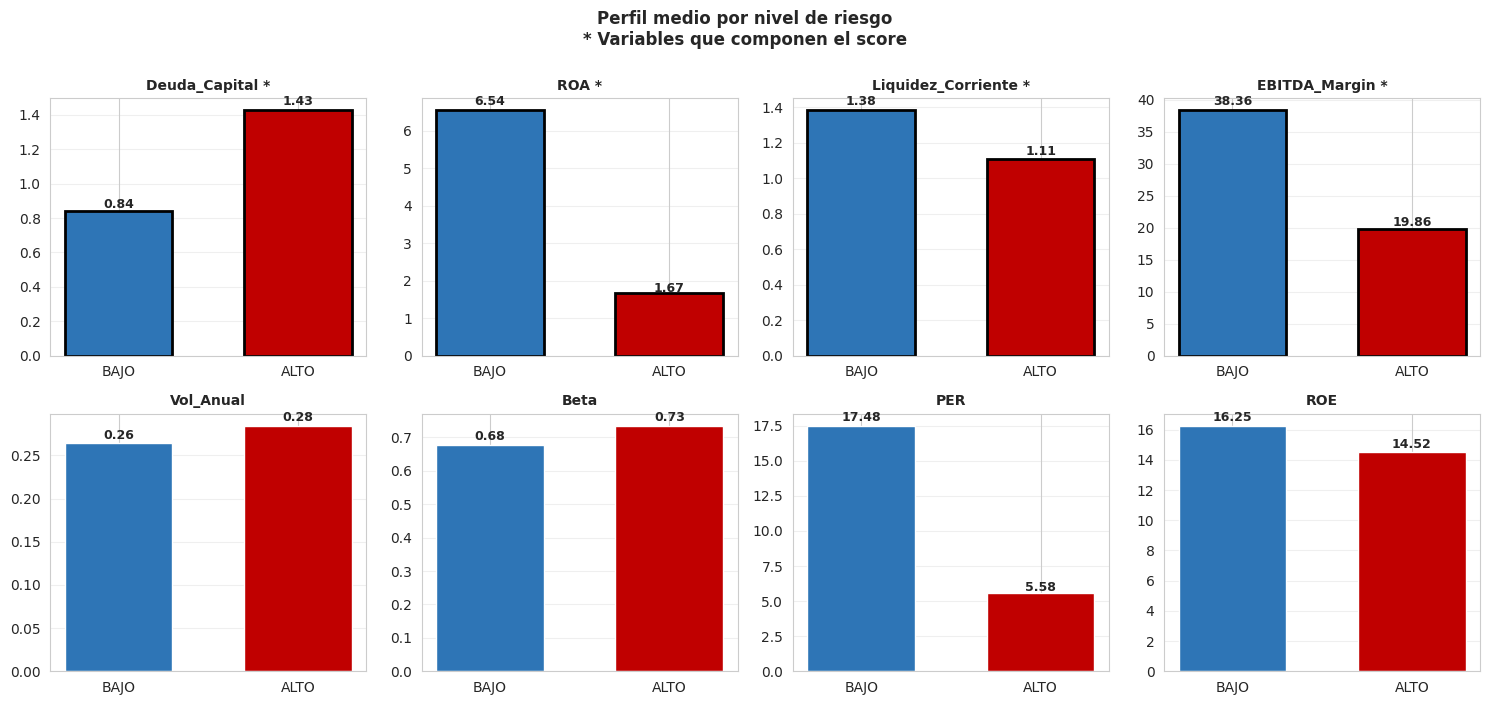

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
vars_perfil = ['Deuda_Capital', 'ROA', 'Liquidez_Corriente', 'EBITDA_Margin',
               'Vol_Anual', 'Beta', 'PER', 'ROE']
for ax, var in zip(axes.flatten(), vars_perfil):
    vals = perfil[var].values
    es_score = var in VARS_SCORE
    bars = ax.bar(['BAJO', 'ALTO'], vals, color=['#2E75B6', '#C00000'],
                  edgecolor='black' if es_score else 'white',
                  linewidth=2 if es_score else 1, width=0.6)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2,
                b.get_height() + abs(b.get_height())*0.02,
                f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')
    titulo = var + ' *' if es_score else var
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
fig.suptitle('Perfil medio por nivel de riesgo\n* Variables que componen el score',
             fontsize=12, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### Mapa bidimensional del riesgo fundamental

Situamos las 35 empresas en el plano definido por Deuda_Capital (X) y ROA (Y) para visualizar la lógica del Score.

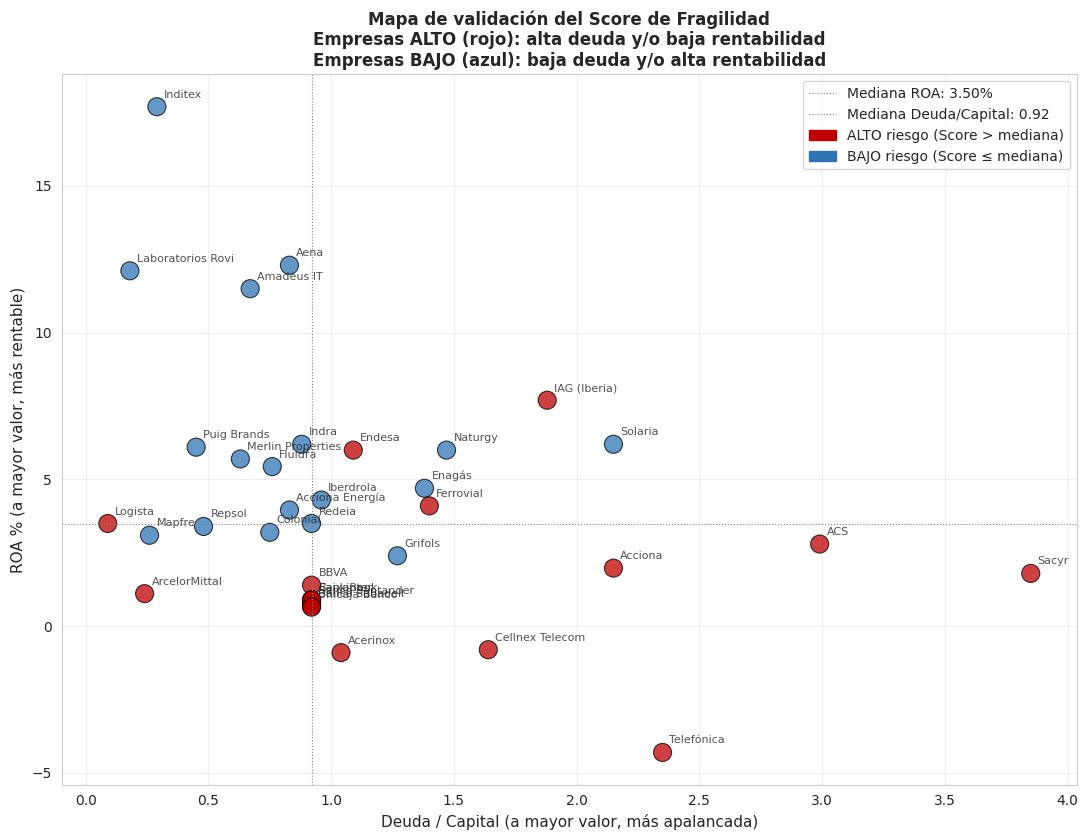

In [22]:
fig, ax = plt.subplots(figsize=(11, 8.5))
colors = ['#C00000' if v == 1 else '#2E75B6' for v in df['Y_RiesgoAlto']]
ax.scatter(df['Deuda_Capital'], df['ROA'], c=colors, s=170, alpha=0.75,
           edgecolors='black', linewidths=0.8)

for i, row in df.iterrows():
    ax.annotate(row['Empresa'], (row['Deuda_Capital'], row['ROA']),
                fontsize=8, alpha=0.8, ha='left', va='bottom',
                xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('Deuda / Capital (a mayor valor, más apalancada)', fontsize=11)
ax.set_ylabel('ROA % (a mayor valor, más rentable)', fontsize=11)
ax.set_title('Mapa de validación del Score de Fragilidad\n'
             'Empresas ALTO (rojo): alta deuda y/o baja rentabilidad\n'
             'Empresas BAJO (azul): baja deuda y/o alta rentabilidad',
             fontsize=12, fontweight='bold')

ax.axhline(df['ROA'].median(), color='gray', linestyle=':', linewidth=0.8,
           label=f'Mediana ROA: {df["ROA"].median():.2f}%')
ax.axvline(df['Deuda_Capital'].median(), color='gray', linestyle=':', linewidth=0.8,
           label=f'Mediana Deuda/Capital: {df["Deuda_Capital"].median():.2f}')

ax.grid(alpha=0.3)
leg = [mpatches.Patch(color='#C00000', label='ALTO riesgo (Score > mediana)'),
       mpatches.Patch(color='#2E75B6', label='BAJO riesgo (Score ≤ mediana)')]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + leg, fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()

**Patrones que confirman la validez del Score:**

1. **Cuadrante superior izquierdo** (alta rentabilidad, baja deuda): empresas BAJO en azul → Inditex, Rovi, Aena, Amadeus IT.
2. **Cuadrante inferior derecho** (baja rentabilidad, alta deuda): empresas ALTO en rojo → Telefónica, Sacyr, ACS, Acciona.
3. **Centro vertical** (Deuda = mediana): se ven agrupados los 6 bancos por la imputación. Su clasificación depende solo del ROA.
4. **Zona frontera**: empresas como Iberdrola, Endesa, Naturgy, Acciona Energía cerca de las medianas, ambiguas. Serán las que producirán más errores en los modelos.

### Matriz de correlación completa

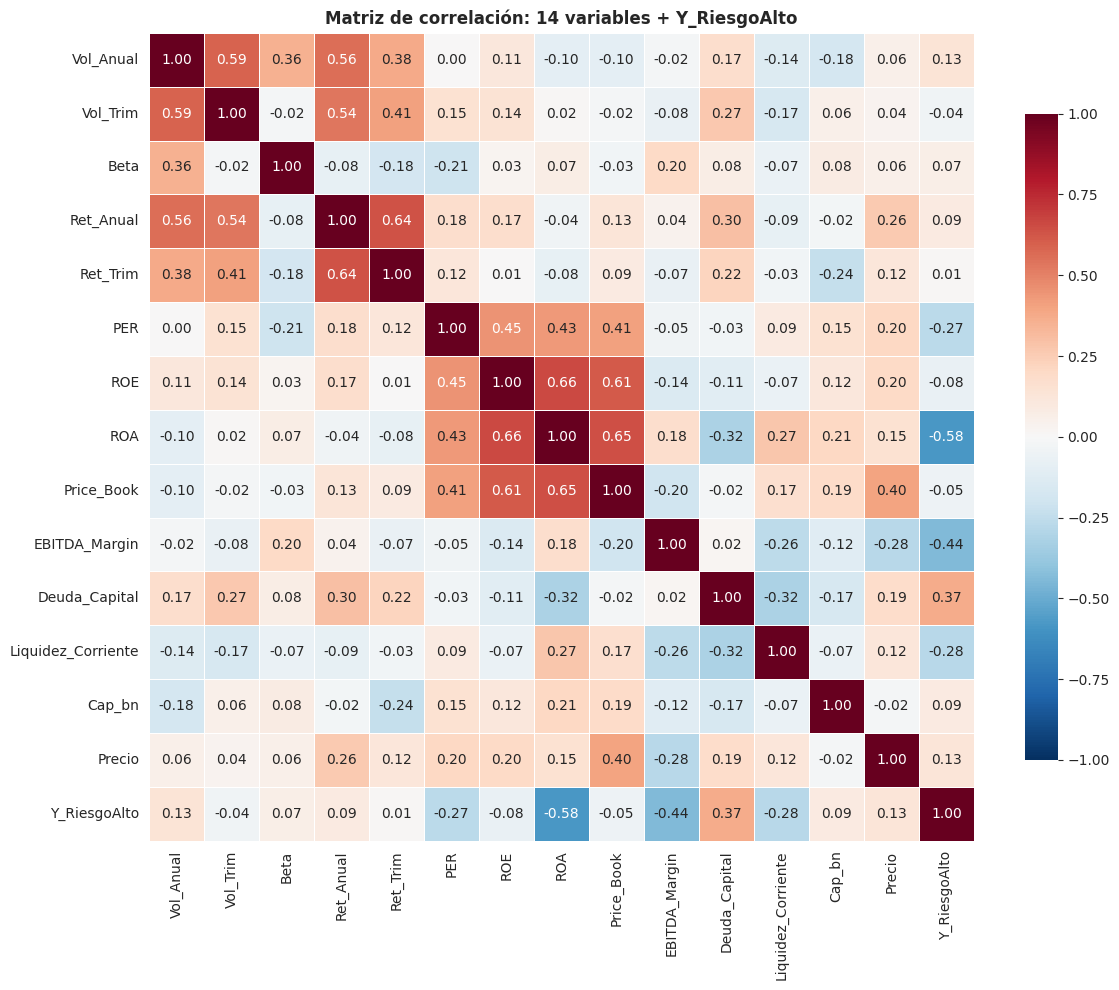

In [23]:
plt.figure(figsize=(12, 10))
sns.heatmap(corrs, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlación: 14 variables + Y_RiesgoAlto',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Exportación del dataset final

Las dummies sectoriales se han eliminado del dataset, manteniendo la coherencia narrativa (no se usan como predictores). La columna `Sector` (texto) sigue disponible para análisis descriptivos sectoriales en el notebook de Análisis. El dataset final pasa de 33 columnas a 19.

In [24]:
# Construir el dataset final - SIN dummies sectoriales
columnas_finales = (
    ['Empresa', 'Ticker', 'Sector'] +
    VARS_NUM +
    ['Score_Fragilidad', 'Y_RiesgoAlto']
)
df_export = df_final[columnas_finales]

df_export.to_excel('Dataset_Final_Modelizacion_IBEX35.xlsx', index=False)

print(f'Dataset final guardado.')
print(f'Dimensiones: {df_export.shape[0]} filas x {df_export.shape[1]} columnas')
print(f'Nulos: {df_export.isnull().sum().sum()}')
print(f'\nColumnas: {df_export.columns.tolist()}')
print(f'\nDistribución Y_RiesgoAlto: {df_export["Y_RiesgoAlto"].value_counts().to_dict()}')

Dataset final guardado.
Dimensiones: 35 filas x 19 columnas
Nulos: 0

Columnas: ['Empresa', 'Ticker', 'Sector', 'Vol_Anual', 'Vol_Trim', 'Beta', 'Ret_Anual', 'Ret_Trim', 'PER', 'ROE', 'ROA', 'Price_Book', 'EBITDA_Margin', 'Deuda_Capital', 'Liquidez_Corriente', 'Cap_bn', 'Precio', 'Score_Fragilidad', 'Y_RiesgoAlto']

Distribución Y_RiesgoAlto: {0: 18, 1: 17}


---

## Resumen del proceso

| Etapa | Acción | Resultado |
|---|---|---|
| 3.2.1 Extracción | Carga del dataset bruto (35×17) y construcción de Score_Fragilidad + Y_RiesgoAlto | 18 BAJO / 17 ALTO |
| 3.2.1 (cont.) | Anticipación de la crítica de circularidad + nota sobre naturaleza relativa | Defensa metodológica blindada |
| 3.2.2 Exploración | Histogramas (distribuciones y asimetrías) | Justifica uso de mediana y normalización |
| 3.2.2 Limpieza | Imputación definitiva de 22 nulos por mediana; 34 outliers conservados | Dataset íntegro sin nulos |
| 3.2.3 Transformación | StandardScaler sobre las 14 variables numéricas | Variables a media 0, std 1 |
| 3.2.3 (cont.) | Argumento anti-tautología sobre el ranking de correlaciones | Validación de coherencia teórica |
| 3.2.4 Visualización | Score por empresa, boxplots por clase, scatter de validación | Validación gráfica de Y_RiesgoAlto |
| Exportación | Dataset final SIN dummies (35×19) | Pipeline limpio y coherente |

**El dataset final (`Dataset_Final_Modelizacion_IBEX35.xlsx`) constituye el input directo para el notebook de Análisis del Dato.**